In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Argenprop_limpio.csv", index_col=0)


In [3]:
df.head()

,Precio,Expensas,Calle,Altura,Piso,Link,Ambientes,Dormitorios,Baños,Estado,...,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m,Antiguedad_imputada
1,150000.0,260000.0,Bulnes,1600.0,No disponible,https://www.argenprop.com/departamento-en-vent...,3,2,1.0,Excelente,...,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19,0
2,330000.0,203300.0,ARAOZ,1200.0,8,https://www.argenprop.com/departamento-en-vent...,4,3,2.0,Bueno,...,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10,1
3,270000.0,300000.0,Honduras,3900.0,2,https://www.argenprop.com/departamento-en-vent...,4,2,2.0,Excelente,...,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5,0
4,570000.0,1000000.0,Castex,3300.0,No disponible,https://www.argenprop.com/departamento-en-vent...,4,3,3.0,No disponible,...,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7,0
5,98000.0,150000.0,GURRUCHAGA,2100.0,5,https://www.argenprop.com/departamento-en-vent...,1,1,1.0,Muy Bueno,...,153.610169,5,461.483469,393.568008,85.286744,6,378.802881,Avenida Raúl Scalabrini Ortiz,7,0


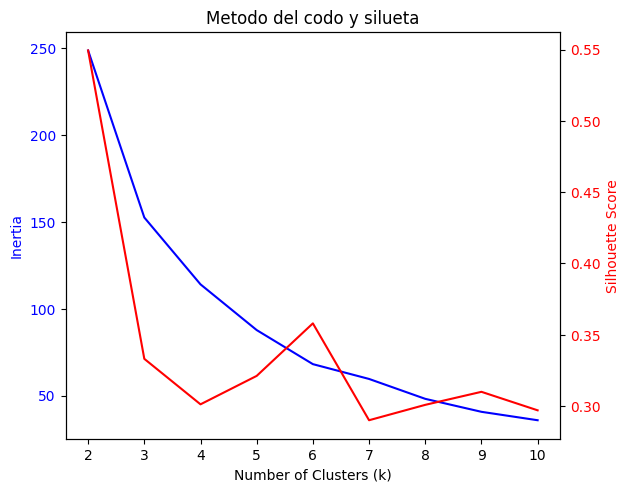

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features_cluster = [
    'Precio',
    'Expensas',
    'Sup_Cubierta_m2',
    'Sup_Total_m2',
    'Ambientes',
    'Dormitorios',
    'Ba\u00f1os',
    'Antiguedad'
]

barrio_features = (
    df.groupby('Barrio')[features_cluster]
      .mean()
      .dropna()
)

scaler = StandardScaler()
X = scaler.fit_transform(barrio_features)

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots()

ax1.plot(k_range, inertia, 'b-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'r-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

fig.tight_layout()
plt.title('Metodo del codo y silueta')
plt.show()


In [13]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

barrio_features = barrio_features.copy()
barrio_features['Cluster'] = labels

df['Cluster'] = df['Barrio'].map(barrio_features['Cluster']).astype('Int64')

barrio_features.sort_values('Cluster')


,Precio,Expensas,Sup_Cubierta_m2,Sup_Total_m2,Ambientes,Dormitorios,Baños,Antiguedad,Cluster
Barrio,,,,,,,,,
Almagro,121432.455253,177030.348801,56.224030,62.116996,2.408560,1.610895,1.319066,44.392996,0
Boedo,116225.537879,165821.772614,58.968880,67.573813,2.537879,1.659091,1.212121,41.030303,0
La Boca,84570.000000,133034.253060,53.609764,60.391157,2.477778,1.655556,1.166667,42.288889,0
Nueva Pompeya,78839.588235,146706.312444,43.120580,51.900000,2.058824,1.294118,1.058824,44.235294,0
Parque Patricios,96687.147368,145955.495391,53.737467,62.157333,2.505263,1.610526,1.115789,41.168421,0
Paternal,104990.434783,158962.191948,53.276957,56.845362,2.304348,1.521739,1.130435,33.826087,0
San Cristobal,95592.500000,158038.818572,55.554640,60.542750,2.600000,1.750000,1.187500,43.275000,0
Velez Sarsfield,108689.340426,166461.961799,55.236936,65.210496,2.531915,1.723404,1.212766,35.936170,0
Villa Soldati,109887.096774,112912.519436,53.633813,59.736839,2.354839,1.483871,1.290323,35.193548,0


In [14]:
df[df["Cluster"]==0]["Barrio"].unique()

array(['Almagro', 'San Cristobal', 'Villa Soldati', 'Parque Patricios',
       'Boedo', 'La Boca', 'Paternal', 'Versalles', 'Velez Sarsfield',
       'Nueva Pompeya', 'Villa Riachuelo'], dtype=object)

In [15]:
df[df["Cluster"]==1]["Barrio"].unique()

array(['Puerto Madero'], dtype=object)

In [16]:
df[df["Cluster"]==2]["Barrio"].unique()

array(['Palermo', 'Nuñez', 'Flores', 'Belgrano', 'Parque Chacabuco',
       'Caballito', 'Floresta', 'Agronomia', 'Villa Gral. Mitre',
       'Monte Castro', 'Villa Lugano', 'Villa Ortuzar'], dtype=object)

In [17]:
df[df["Cluster"]==3]["Barrio"].unique()

array(['Saavedra', 'Colegiales', 'Villa Crespo', 'Villa Urquiza',
       'Coghlan', 'Chacarita', 'Villa Devoto', 'Liniers',
       'Villa Pueyrredon', 'Villa Real', 'Villa Del Parque',
       'Parque Avellaneda', 'Parque Chas', 'Villa Santa Rita',
       'Villa Luro', 'Mataderos'], dtype=object)

In [18]:
df[df["Cluster"]==4]["Barrio"].unique()

array(['Retiro', 'Recoleta'], dtype=object)

In [19]:
df[df["Cluster"]==5]["Barrio"].unique()

array(['Balvanera', 'Monserrat', 'San Nicolas', 'Constitucion',
       'Barracas', 'San Telmo'], dtype=object)

In [21]:
df.groupby("Cluster")[[
    'Precio',
    'Expensas',
    'Sup_Cubierta_m2',
    'Sup_Total_m2',
    'Ambientes',
    'Dormitorios',
    'Ba\u00f1os',
    'Antiguedad'
]].mean()

,Precio,Expensas,Sup_Cubierta_m2,Sup_Total_m2,Ambientes,Dormitorios,Baños,Antiguedad
Cluster,,,,,,,,
0,107642.280049,158603.299581,55.389397,62.342297,2.462668,1.627907,1.222766,41.624235
1,502622.920000,582512.876291,101.538868,110.462907,2.706667,1.786667,2.026667,16.413333
2,186824.325288,244722.965355,66.752284,75.244169,2.705931,1.852142,1.438633,36.361614
3,161633.818513,208167.756854,58.854349,67.711193,2.469059,1.652626,1.361934,29.537181
4,215368.638138,314469.140351,81.376150,87.529990,2.947447,2.072072,1.594595,48.831832
5,116649.238628,184605.346284,62.322934,67.194720,2.634601,1.809098,1.298285,49.789709
